# LeetCode #606: Construct String from Binary Tree

https://leetcode.com/problems/construct-string-from-binary-tree/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Iterative (stack-based)** | $O(n)$ | $O(n)$ |
| **Optimal: DFS Pre-order with Parentheses ★** | $O(n)$ | $O(n)$ |

---

## Understanding the Methods

### Iterative (stack-based)
Use an explicit stack and track which nodes have been processed. More verbose and requires special handling for the empty-left-child placeholder case.

### Optimal: DFS Pre-order with Parentheses ★
Pre-order DFS: emit node value, then wrap left subtree in `()` (omit only when both children are null), wrap right subtree in `()` (always omit when right is null). Three simple cases handle all scenarios.

**Why this is better than Iterative:** The recursive structure directly mirrors the output format — the three `if/return` cases map one-to-one to the grammar rules of the output string.

**Constraints:**
* The number of nodes in the tree is in the range $[1, 10^4]$.
* $-1000 \le$ Node.val $\le 1000$

## Solutions

### C#

In [ ]:
public string Tree2str(TreeNode root) {
    if (root == null) return "";
    string val = root.val.ToString();
    // Leaf node: no parentheses needed
    if (root.left == null && root.right == null) return val;
    // Right child absent: emit left only (must include "()" for left even if empty? No, left exists)
    if (root.right == null) return $"{val}({Tree2str(root.left)})";
    // Both children present (left may be empty — emit "()" as placeholder)
    return $"{val}({Tree2str(root.left)})({Tree2str(root.right)})";
}

### Python

In [ ]:
def tree2str(self, root: Optional[TreeNode]) -> str:
    if not root:
        return ""
    val = str(root.val)
    # Leaf node: no parentheses needed
    if not root.left and not root.right:
        return val
    # Right child absent: left subtree only
    if not root.right:
        return f"{val}({self.tree2str(root.left)})"
    # Both children: left may produce "()" placeholder if null
    return f"{val}({self.tree2str(root.left)})({self.tree2str(root.right)})" 

### Go

In [ ]:
import "strconv"

func tree2str(root *TreeNode) string {
    if root == nil { return "" }
    val := strconv.Itoa(root.Val)
    // Leaf node: no parentheses needed
    if root.Left == nil && root.Right == nil { return val }
    // Right child absent: left subtree only
    if root.Right == nil { return val + "(" + tree2str(root.Left) + ")" }
    // Both children: left may be "()" placeholder if null
    return val + "(" + tree2str(root.Left) + ")(" + tree2str(root.Right) + ")"
}

### Rust

In [ ]:
pub fn tree2str(root: Option<Rc<RefCell<TreeNode>>>) -> String {
    fn dfs(node: &Option<Rc<RefCell<TreeNode>>>) -> String {
        let n = match node { None => return String::new(), Some(n) => n.borrow() };
        let val = n.val.to_string();
        let (l, r) = (n.left.clone(), n.right.clone());
        drop(n);
        // Leaf node: no parentheses needed
        if l.is_none() && r.is_none() { return val; }
        // Right child absent: left subtree only
        if r.is_none() { return format!("{}({})", val, dfs(&l)); }
        // Both children: left may produce empty string "()" placeholder
        format!("{}({})({})", val, dfs(&l), dfs(&r))
    }
    dfs(&root)
}

## Example Scenarios

**1. Common Case**
**Input:** root = [1,2,3,4]
DFS: 1 has both children → "1(" + tree2str(2) + ")(" + tree2str(3) + ")". tree2str(2): has left child 4, no right → "2(4)". tree2str(3): leaf → "3". Result: **"1(2(4))(3)"**.

**2. Slightly Complex**
**Input:** root = [1,2,3,null,4]
Node 2 has right child 4 but no left child → must emit "()" as left placeholder. tree2str(2) = "2()(4)". tree2str(3) = "3". Result: **"1(2()(4))(3)"** — the empty "()" is critical to distinguish left-absent from right-absent.

**3. Edge Case: Time Factor**
**Input:** A right-skewed tree [1,null,2,null,3,...,null,n]
Each node is a right child with no left child, so the "()(right)" pattern is emitted $n-1$ times. Total string length is $O(n^2)$ in the worst case (each level prepends the parent value). Recursion depth = $n$.

**4. Edge Case: Space Factor**
**Input:** A balanced tree where all nodes have both children, depth $= \log_2 n$
Call stack depth is $O(\log n)$; output string length is $O(n)$ since each node contributes its value plus 2 parentheses. No space wasted on placeholder "()" — right-absent case never triggers.

**5. Almost-Impossible but Plausible**
**Input:** root = [-1000, -1000, -1000] (all negative values at min boundary)
Values with '-' sign are one extra character wide. Verify the output "-1000(-1000)(-1000)" correctly handles negative values — no off-by-one in digit parsing or string formatting.

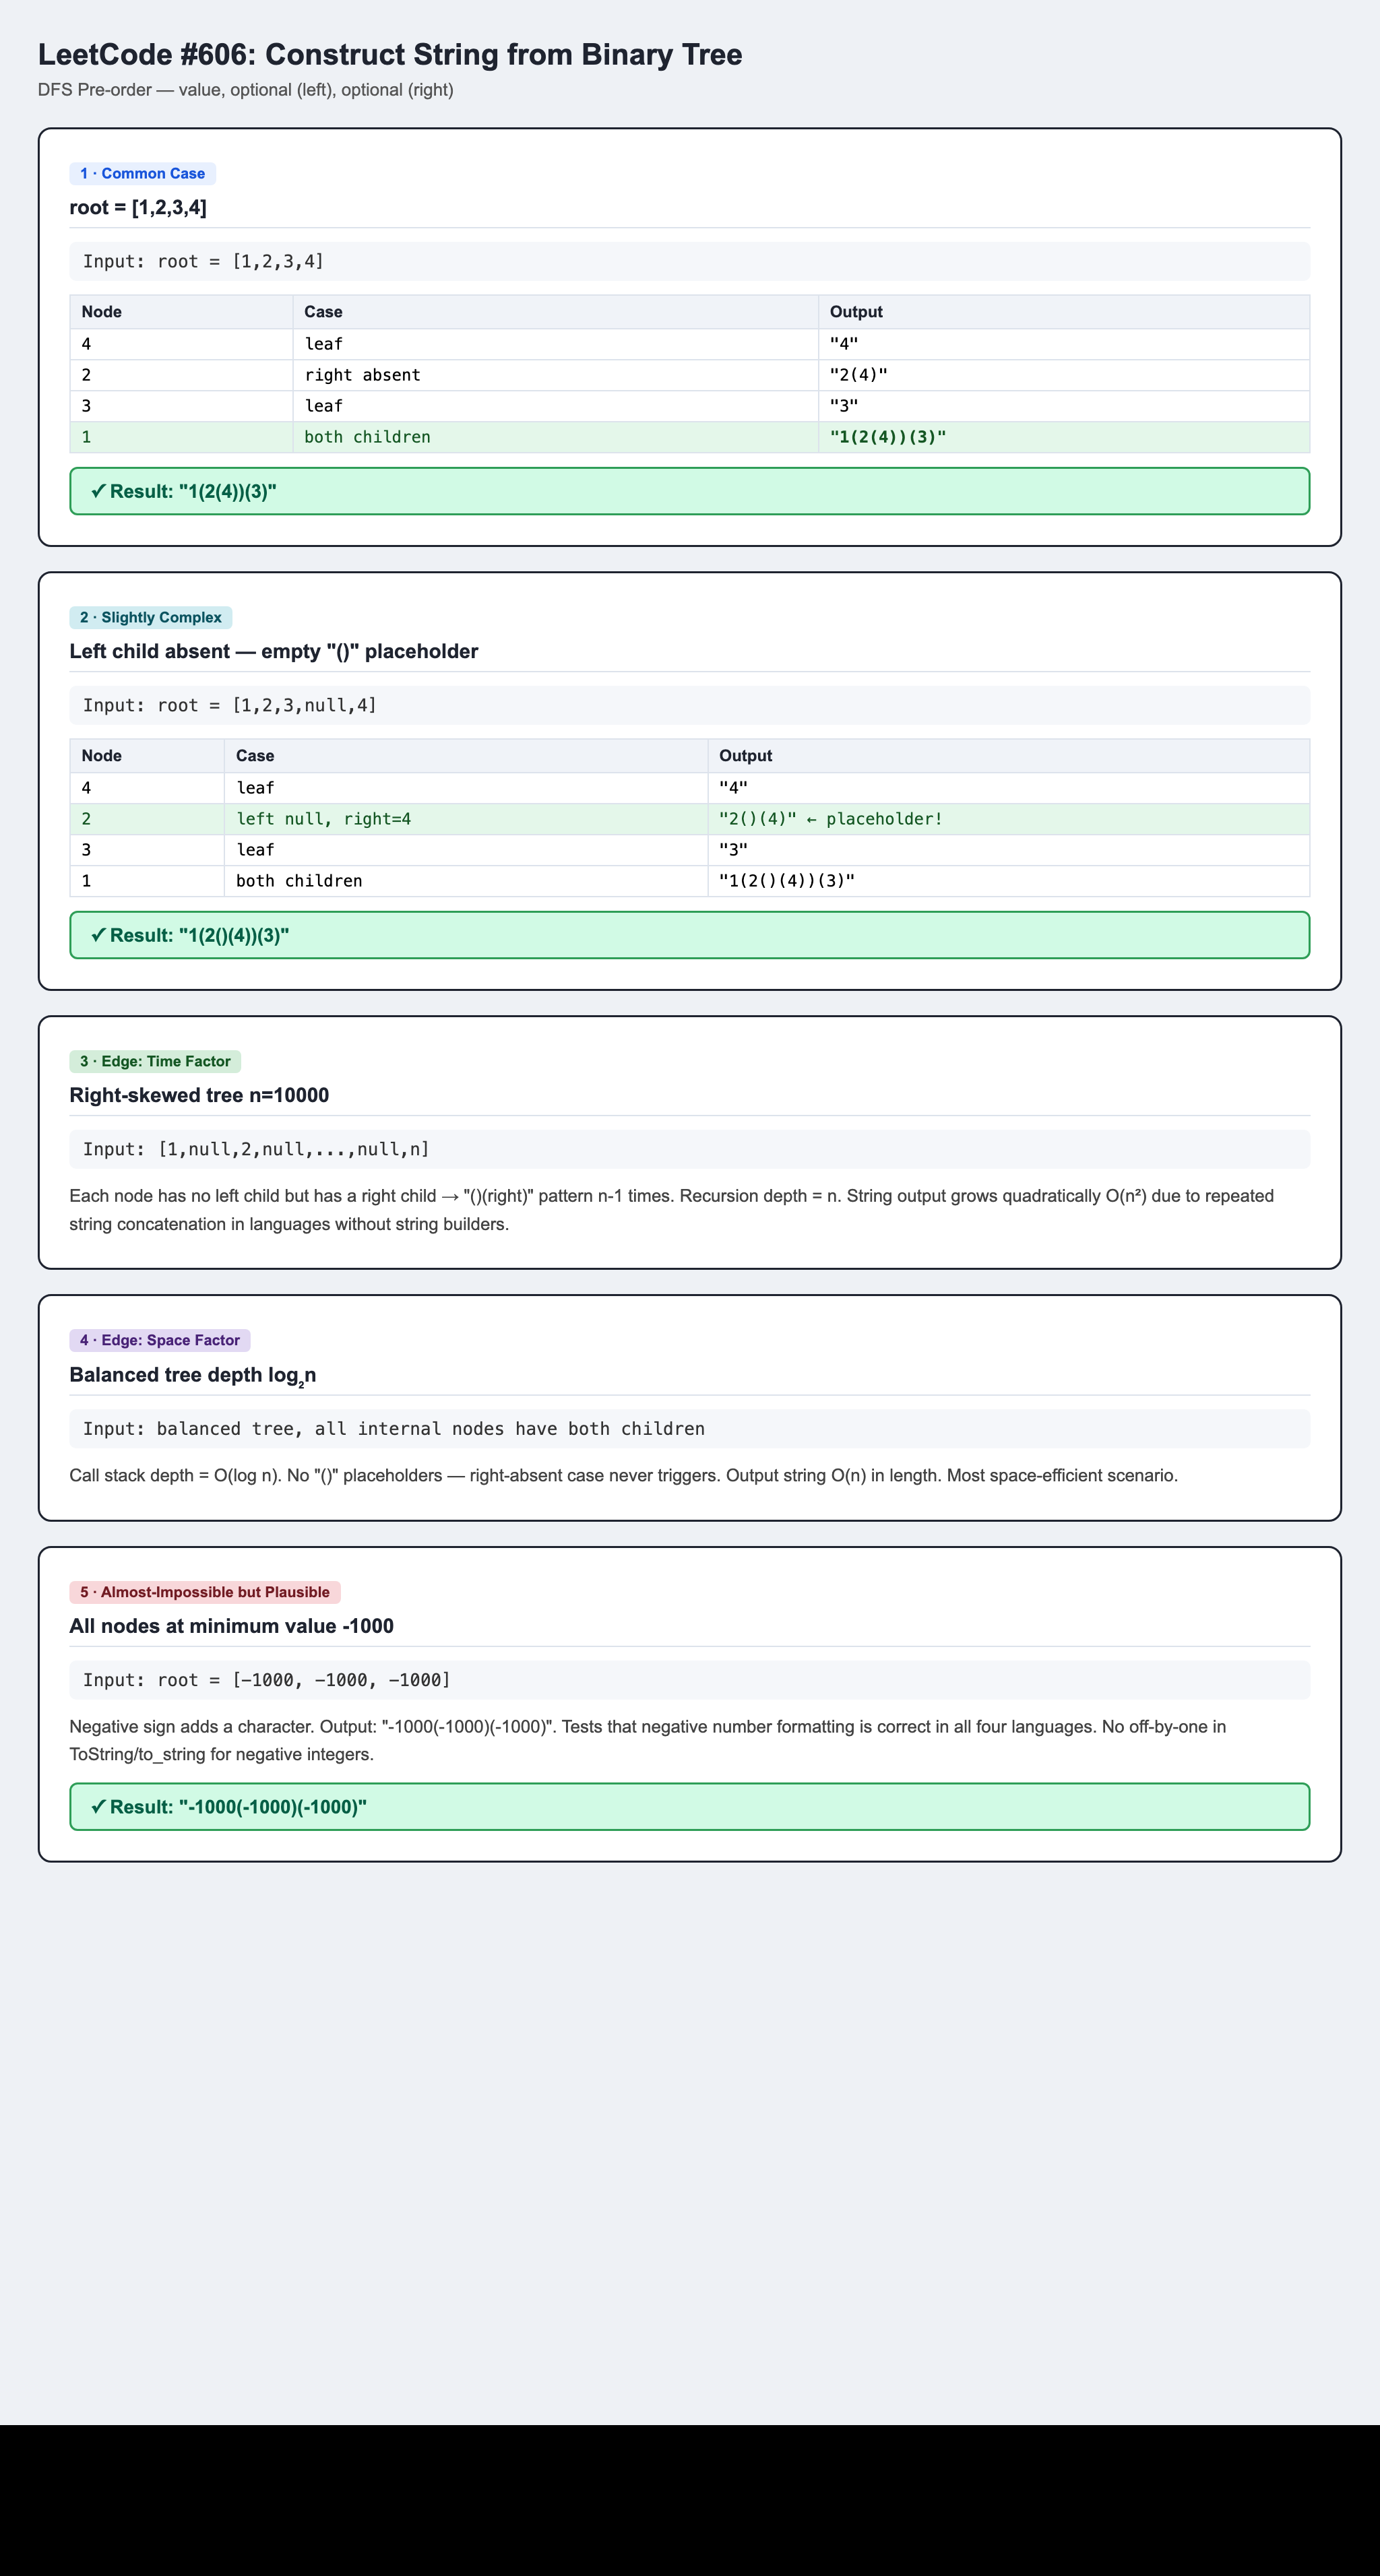